In [1]:
# Célula 1: Imports 
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from PIL import Image

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# Célula 2: Carregamento de imagens (normalizado 0–1)

def carregar_imagens_com_caminho(pasta, label, target_size=(128, 128)):
    imagens, labels, caminhos = [], [], []
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    for arquivo in sorted(os.listdir(pasta)):
        caminho = os.path.join(pasta, arquivo)
        if caminho.lower().endswith(exts):
            img = load_img(caminho, target_size=target_size, color_mode="rgb")
            arr = img_to_array(img).astype("float32") / 255.0  # 🔧 normalização
            imagens.append(arr)
            labels.append(label)
            caminhos.append(caminho)
    return imagens, labels, caminhos

pasta_boas  = "dados/boas"
pasta_ruins = "dados/ruins"

boas,  y_boa,  caminhos_boas  = carregar_imagens_com_caminho(pasta_boas,  label=1)
ruins, y_ruim, caminhos_ruins = carregar_imagens_com_caminho(pasta_ruins, label=0)

X = np.array(boas + ruins, dtype="float32")
y = np.array(y_boa + y_ruim, dtype="int32")
caminhos = np.array(caminhos_boas + caminhos_ruins)

print(f"Total de imagens carregadas: {len(X)}")
print(f"Formato das imagens: {X[0].shape}")
classes, cont = np.unique(y, return_counts=True)
print(f"Distribuição de classes (label:cont): {dict(zip(classes, cont))}")

Total de imagens carregadas: 827
Formato das imagens: (128, 128, 3)
Distribuição de classes (label:cont): {np.int32(0): np.int64(427), np.int32(1): np.int64(400)}


In [3]:
# Célula 3: Split (treino/val/teste) + checagens de sanidade

X_train_val, X_test, y_train_val, y_test, caminhos_train_val, caminhos_test = train_test_split(
    X, y, caminhos, test_size=0.30, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val, caminhos_train, caminhos_val = train_test_split(
    X_train_val, y_train_val, caminhos_train_val,
    test_size=0.132, stratify=y_train_val, random_state=SEED
)

def resumo_conjunto(nome, y_dados):
    classes, contagens = np.unique(y_dados, return_counts=True)
    print(f"\n🔹 {nome.upper()} - Total: {len(y_dados)} imagens")
    for c, count in zip(classes, contagens):
        rotulo = "BOA" if c == 1 else "RUIM"
        print(f"  - {rotulo}: {count} imagens")

resumo_conjunto("Treino", y_train)
resumo_conjunto("Validação", y_val)
resumo_conjunto("Teste", y_test)

# Checagens de vazamento e escala
overlap_val  = set(caminhos_train) & set(caminhos_val)
overlap_test = set(caminhos_train) & set(caminhos_test)
print("\nInterseção treino–validação:", len(overlap_val))
print("Interseção treino–teste    :", len(overlap_test))
if overlap_val:
    print("⚠️ Vazamento treino–validação (exemplos):", list(sorted(overlap_val))[:5])
if overlap_test:
    print("⚠️ Vazamento treino–teste (exemplos):", list(sorted(overlap_test))[:5])

print("\nEscala X_train (min,max):", float(X_train.min()), float(X_train.max()))
print("Escala X_val   (min,max):", float(X_val.min()),   float(X_val.max()))
print("Escala X_test  (min,max):", float(X_test.min()),  float(X_test.max()))

# Pesos de classe (se desbalanceado)
from collections import Counter
contagens = Counter(y_train.tolist())
maj = max(contagens.values()); minc = min(contagens.values())
if minc > 0 and (maj / minc) >= 1.5:
    cw = {0: maj / contagens.get(0, 1), 1: maj / contagens.get(1, 1)}
    print("\nclass_weight aplicado:", cw)
else:
    cw = None
    print("\nclass_weight não necessário (balanceado).")



🔹 TREINO - Total: 501 imagens
  - RUIM: 258 imagens
  - BOA: 243 imagens

🔹 VALIDAÇÃO - Total: 77 imagens
  - RUIM: 40 imagens
  - BOA: 37 imagens

🔹 TESTE - Total: 249 imagens
  - RUIM: 129 imagens
  - BOA: 120 imagens

Interseção treino–validação: 0
Interseção treino–teste    : 0

Escala X_train (min,max): 0.0 1.0
Escala X_val   (min,max): 0.0 1.0
Escala X_test  (min,max): 0.0 1.0

class_weight não necessário (balanceado).


In [5]:
# Célula 4: Modelo CNN

modelo = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelo.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Célula 5: Treinamento (validation_data correto + callbacks)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

fit_kwargs = dict(
    x=X_train, y=y_train,
    validation_data=(X_val, y_val),   # 🔒 validação é o conjunto de VALIDAÇÃO
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

if cw is not None:
    fit_kwargs["class_weight"] = cw

history = modelo.fit(**fit_kwargs)

# Sanidade: primeiras perdas não devem ser zero
print("loss[:3]    =", [round(v, 6) for v in history.history["loss"][:3]])
print("val_loss[:3]=", [round(v, 6) for v in history.history["val_loss"][:3]])


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.5215 - loss: 0.8867 - val_accuracy: 0.7013 - val_loss: 0.5556 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.7340 - loss: 0.5169 - val_accuracy: 0.7403 - val_loss: 0.4641 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - accuracy: 0.8391 - loss: 0.3645 - val_accuracy: 0.8052 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 284ms/step - accuracy: 0.8817 - loss: 0.3230 - val_accuracy: 0.8831 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step - accuracy: 0.9052 - loss: 0.2606 - val_accuracy: 0.8961 - val_loss: 0.2990 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 371ms/step - accuracy: 0.9128 - loss: 0.2024 - val_accuracy: 0.8961 - val_loss: 0.2395 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.9346 - loss: 0.

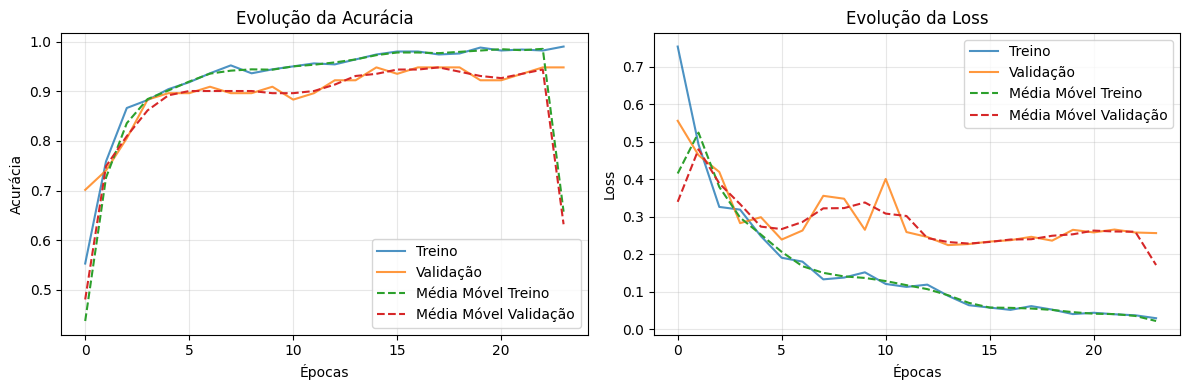

In [13]:
# Célula — Plots de Acurácia e Loss (com médias móveis e legendas em PT-BR)

import numpy as np
import matplotlib.pyplot as plt

def _moving_avg(x, k=9):
    x = np.asarray(x, dtype=float)
    if x.size == 0 or k <= 1: 
        return x
    w = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, w, mode="same")

def plot_history_pt(history, janela_media=9):
    # Compatibilidade com diferentes chaves do Keras
    tr_acc = history.history.get("accuracy", history.history.get("acc", []))
    va_acc = history.history.get("val_accuracy", history.history.get("val_acc", []))
    tr_loss = history.history.get("loss", [])
    va_loss = history.history.get("val_loss", [])

    if not (len(tr_acc) and len(va_acc) and len(tr_loss) and len(va_loss)):
        print("⚠️ Não encontrei todas as chaves no history. Verifique se o treino foi executado.")
        print("Keys disponíveis:", list(history.history.keys()))
        return

    # Médias móveis (tracejadas)
    tr_acc_ma = _moving_avg(tr_acc, janela_media)
    va_acc_ma = _moving_avg(va_acc, janela_media)
    tr_loss_ma = _moving_avg(tr_loss, janela_media)
    va_loss_ma = _moving_avg(va_loss, janela_media)

    plt.figure(figsize=(12, 4))

    # --- Gráfico de Acurácia ---
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(tr_acc, label="Treino", alpha=0.8)
    ax1.plot(va_acc, label="Validação", alpha=0.8)
    ax1.plot(tr_acc_ma, "--", label="Média Móvel Treino")
    ax1.plot(va_acc_ma, "--", label="Média Móvel Validação")
    ax1.set_title("Evolução da Acurácia")
    ax1.set_xlabel("Épocas")
    ax1.set_ylabel("Acurácia")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # --- Gráfico de Loss ---
    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(tr_loss, label="Treino", alpha=0.8)
    ax2.plot(va_loss, label="Validação", alpha=0.8)
    ax2.plot(tr_loss_ma, "--", label="Média Móvel Treino")
    ax2.plot(va_loss_ma, "--", label="Média Móvel Validação")
    ax2.set_title("Evolução da Loss")
    ax2.set_xlabel("Épocas")
    ax2.set_ylabel("Loss")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Chame assim após o fit:
plot_history_pt(history, janela_media=3)  # ajuste a janela se quiser suavizar mais/menos


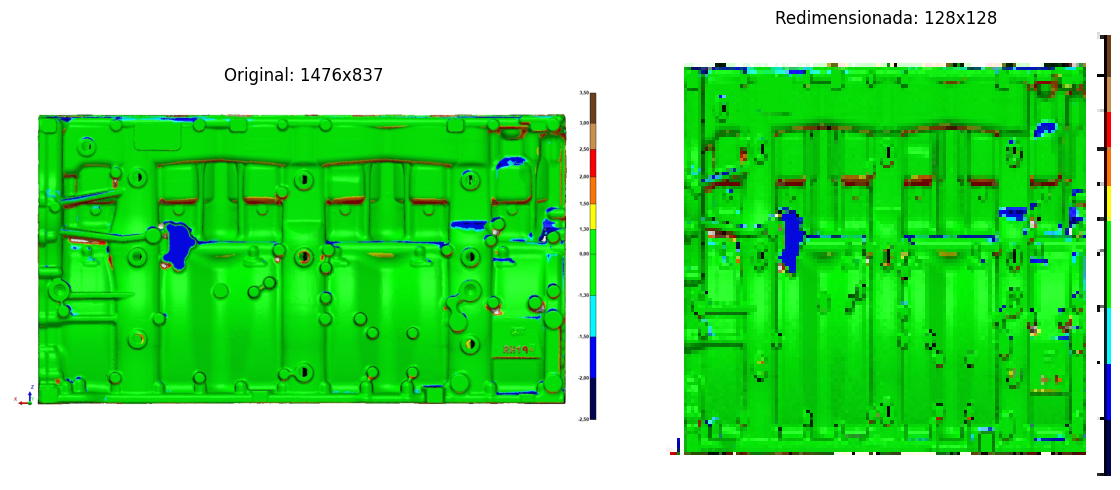

In [7]:
# Célula 7: Visualização (opcional) — corrigindo o título da dimensão

caminho_img = 'dados/ruins/Peca_5_imagem_4.jpg'

img_original = load_img(caminho_img)  # resolução original
img_array_original = img_to_array(img_original) / 255.0

img_resized = load_img(caminho_img, target_size=(128, 128))
img_array_resized = img_to_array(img_resized) / 255.0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array_original.astype("float32"))
plt.title(f"Original: {img_original.size[0]}x{img_original.size[1]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_array_resized.astype("float32"))
plt.title("Redimensionada: 128x128")
plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
# Gera um lote de 15 imagens aumentadas
augmented_images = datagen.flow(X_train, y_train, batch_size=15)

# Pega o lote
imgs, labels = next(augmented_images)

# Plota as 15 imagens (3 linhas x 5 colunas)
plt.figure(figsize=(15, 9))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(imgs[i].clip(0, 1))  # Garante que os valores fiquem entre 0 e 1
    plt.title("BOA" if labels[i] == 1 else "RUIM")
    plt.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'datagen' is not defined

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


<Figure size 600x600 with 0 Axes>

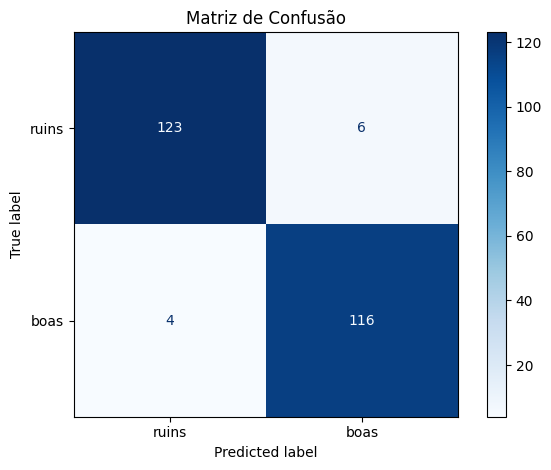

Classe      Precision     Recall
ruins            0.97       0.95
boas             0.95       0.97

Acurácia geral:  0.96


In [9]:
# Célula 6: Avaliação final e matriz de confusão

# Obtém as previsões
y_pred_probs = modelo.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()


labels = ["ruins", "boas"]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

# Cálculo manual das métricas
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0

# Exibição formatada

print(f"{'Classe':<10} {'Precision':>10} {'Recall':>10}")


for idx, classe in enumerate(labels):

    print(f"{classe:<10} {precision[idx]:10.2f} {recall[idx]:10.2f}")

# print(f"\nEspecificidade (RUINS): {especificidade:.4f}") #para saber “Das peças ruins, quantas foram corretamente reconhecidas como ruins?”
# print(f"Sensibilidade (BOAS)  : {sensibilidade:.4f}")    #para saber “Das peças Boas, quantas foram corretamente reconhecidas como boas?”
print(f"\nAcurácia geral:  {acc:.2f}")

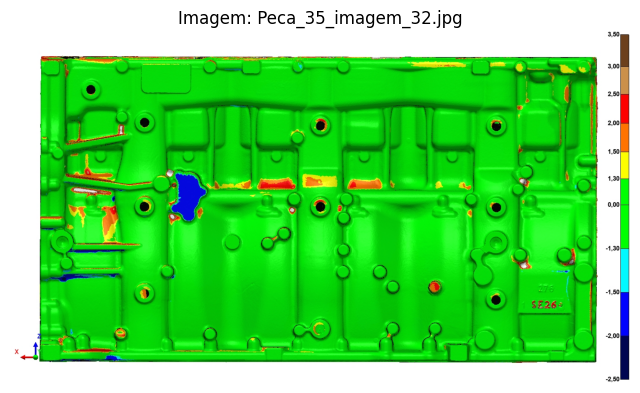

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Classe REAL: RUIM
Classe PREVISTA: RUIM


In [116]:
# Célula 7: Predição individual com visualização da imagem original (sem redimensionamento)
idx = 23  # Errou a 12
# Exibe imagem original (em tamanho real)
img_original = Image.open(caminhos_test[idx])
nome_arquivo = os.path.basename(caminhos_test[idx])

plt.figure(figsize=(8, 8))
plt.imshow(img_original)
plt.title(f"Imagem: {nome_arquivo}")
plt.axis('off')
plt.show()

# Faz predição com a versão 128x128 usada pela rede
pred = modelo.predict(np.expand_dims(X_test[idx], axis=0))[0][0]
classe_real = "BOA" if y_test[idx] == 1 else "RUIM"
classe_prevista = "BOA" if pred > 0.5 else "RUIM"

print(f"Classe REAL: {classe_real}")
print(f"Classe PREVISTA: {classe_prevista}")
# print(f"Probabilidade prevista: {pred:.4f}")